# **EJECUCIÓN COMPLETA DE SEGMENTACIÓN EN CASO CONCRETO**
## (DATOS DE THELOOK)

Se han definido 5 métricas concretas, el clasico RFM, añadiendole 2 métricas adicionales que son L y S.

L(Lenght) -> Representa el tiempo desde que se hace la primera compra a la última dentro de el periodo de tiempo analizado
S(Satisfaction) -> Si se tiene datos de encuestas representa la satisfacción del cliente

# **1. MODELO DE DATOS(DATOS REQUERIDOS)**

Como datos requeridos para la segmentación de clientes, se ha definido una estructura/modelo de datos, con los datos estrictamente necesarios para realizar esto

In [42]:
import pandas as pd
from lrfm_basico import ValidadorYMapeador, LRFMExtractor
from k_means import KMeansLRFMSegmenter

Hay que asignar el nombre de la columna que corresponde al dato del modelo, es decir en el caso de thelook, los nombres son: order_id, user_id, created_at, sale_price, product_id

In [43]:
def definir_mapeo():
    mapeo = {
        # OBLIGATORIO
        "customer_id": "user_id",          # <-- Cambia "cliente_codigo" por el nombre de tu columna
        "transaction_id": "order_id",             # <-- Cambia "venta_id" por el nombre de tu columna
        "transaction_date": "created_at",        # <-- Cambia "fecha_venta" por el nombre de tu columna
        "transaction_amount": "sale_price",      # <-- Cambia "monto_total" por el nombre de tu columna
        
        # CAMPOS DE LA MÉTRICA S(PRUEBAS)
        #"quality_rating": "rating_producto",      
        #"delivery_rating": "rating_envio",        
        #"service_rating": "rating_atencion"       
    }
    
    return mapeo

# **CALCULO DE METRICAS**

In [44]:
import pandas as pd

df_raw = pd.read_csv("../../data/thelook/procesado/orders_price_client.csv")

mapeo = {
    "customer_id": "user_id",
    "transaction_id": "order_id",
    "transaction_date": "created_at",
    "transaction_amount": "sale_price",
}

ok, errores = ValidadorYMapeador.validar_mapeo(df_raw, mapeo)
if not ok:
    print(errores)
    raise ValueError("Mapeo incorrecto")

df_std = ValidadorYMapeador.aplicar_mapeo(df_raw, mapeo)

extractor = LRFMExtractor(reference_date=None)  # Lo pongo en None para que pille el valor máximo de los datos
df_lrfm = extractor.calcular_lrfm(df_std)

df_lrfm_scored = extractor.add_quantil_scores(df_lrfm, q=5)

df_lrfm.head()


,customer_id,L,R,F,M
0,1,1,1102,1,63.990002
1,10,64,7,2,87.760000
2,1000,0,60,1,70.000000
3,10000,310,2,2,224.980001
4,100000,0,40,1,907.840000


In [27]:
df_lrfm_scored.head()

,customer_id,L,R,F,M,R_score,F_score,M_score,L_score,LRFM_score
0,1,1,1102,1,63.990002,1,1,2,3,3112
1,10,64,7,2,87.760000,5,4,3,4,4543
2,1000,0,60,1,70.000000,4,1,3,1,1413
3,10000,310,2,2,224.980001,5,4,5,5,5545
4,100000,0,40,1,907.840000,5,1,5,1,1515


# **CLUSTERING**

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [46]:
def preparar_clustering(df_lrfm: pd.DataFrame):
    """
    Prepara la matriz X para clustering:
    - log1p en F y M
    - escalado estándar
    """
    df = df_lrfm.copy()

    df["F_log"] = np.log1p(df["F"])
    df["M_log"] = np.log1p(df["M"])

    features = ["L", "R", "F_log", "M_log"]
    X = df[features].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, features


In [47]:
def elegir_k_elbow_silhouette(
    X_scaled: np.ndarray,
    k_min: int = 2,
    k_max: int = 10,
    sample_size: int = 10000,
    random_state: int = 42
):
    """
    Devuelve:
    - ks
    - inertias
    - silhouettes
    - k_recomendado
    """

    n = X_scaled.shape[0]

    # Muestra para silhouette (ligero)
    if n > sample_size:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(n, size=sample_size, replace=False)
        X_sil = X_scaled[idx]
    else:
        X_sil = X_scaled

    ks = list(range(k_min, k_max + 1))
    inertias = []
    silhouettes = []

    for k in ks:
        model = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init="auto"
        )

        labels_full = model.fit_predict(X_scaled)
        inertias.append(model.inertia_)

        try:
            sil = silhouette_score(X_sil, labels_full[:len(X_sil)])
        except Exception:
            sil = np.nan

        silhouettes.append(sil)

    # Elegimos k por silhouette (ignorando NaN)
    sil_series = pd.Series(silhouettes, index=ks)
    k_recomendado = int(sil_series.dropna().idxmax())

    return ks, inertias, silhouettes, k_recomendado


In [48]:
def plot_k_selection(ks, inertias, silhouettes):
    plt.figure()
    plt.plot(ks, inertias, marker="o")
    plt.xlabel("k")
    plt.ylabel("Inertia (SSE)")
    plt.title("Elbow Method")
    plt.xticks(ks)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(ks, silhouettes, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette score (sample)")
    plt.title("Silhouette (versión ligera)")
    plt.xticks(ks)
    plt.tight_layout()
    plt.show()


k recomendado: 2


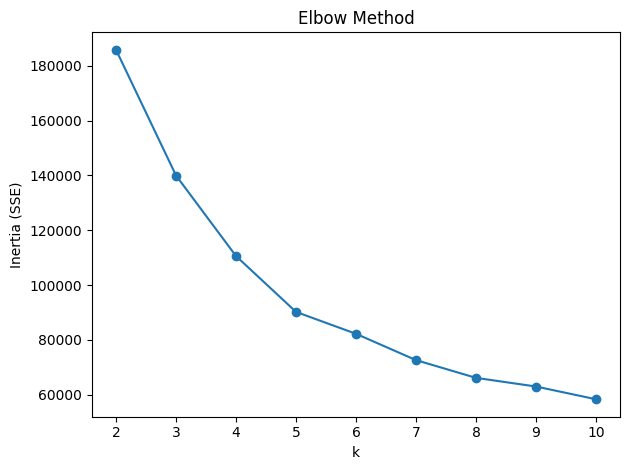

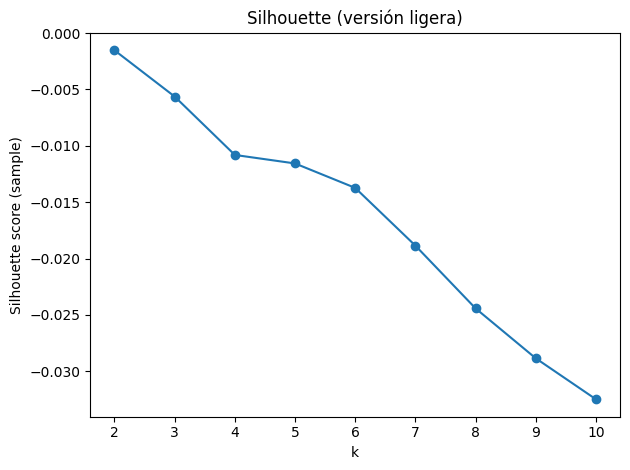

In [49]:
# df_lrfm viene de LRFMExtractor.calcular_lrfm()

X_scaled, features = preparar_clustering(df_lrfm)

ks, inertias, silhouettes, k_opt = elegir_k_elbow_silhouette(
    X_scaled,
    k_min=2,
    k_max=10,
    sample_size=10000
)

print(f"k recomendado: {k_opt}")

plot_k_selection(ks, inertias, silhouettes)


In [28]:
segmenter = KMeansLRFMSegmenter(n_clusters=5)
df_segmentado = segmenter.fit_predict(df_lrfm)

df_segmentado.head()

,customer_id,L,R,F,M,F_log,M_log,segmento_id
0,1,1,1102,1,63.990002,0.693147,4.174233,0
1,10,64,7,2,87.760000,1.098612,4.485936,1
2,1000,0,60,1,70.000000,0.693147,4.262680,4
3,10000,310,2,2,224.980001,1.098612,5.420447,1
4,100000,0,40,1,907.840000,0.693147,6.812169,4


In [29]:
df_segmentado.groupby("segmento_id")[["L","R","F","M"]].mean()

,L,R,F,M
segmento_id,,,,
0,12.320673,713.460109,1.102850,85.675884
1,133.817469,154.893440,2.391492,210.351680
2,566.693736,183.744760,2.869445,253.425908
3,1.806046,181.405274,1.024788,31.544134
4,0.892780,180.486635,1.000000,154.268912


PLOTS

In [51]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_pca_clusters(X_scaled, labels):
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X_scaled)

    plt.figure()
    plt.scatter(Z[:, 0], Z[:, 1], c=labels, s=10)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.title("PCA 2D (clientes coloreados por cluster)")
    plt.tight_layout()
    plt.show()


In [52]:
def plot_cluster_sizes(df_seg, col="segmento_id"):
    counts = df_seg[col].value_counts().sort_index()

    plt.figure()
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel("Cluster")
    plt.ylabel("Número de clientes")
    plt.title("Tamaño de clusters")
    plt.tight_layout()
    plt.show()


In [53]:
def boxplot_por_cluster(df_seg, variable, col_cluster="segmento_id"):
    clusters = sorted(df_seg[col_cluster].unique())
    data = [df_seg.loc[df_seg[col_cluster] == c, variable].values for c in clusters]

    plt.figure()
    plt.boxplot(data, labels=[str(c) for c in clusters], showfliers=False)
    plt.xlabel("Cluster")
    plt.ylabel(variable)
    plt.title(f"{variable} por cluster")
    plt.tight_layout()
    plt.show()


In [54]:
def heatmap_centros_escalados(segmenter):
    centers = segmenter.get_cluster_centers_scaled().values
    feats = segmenter.features_

    plt.figure()
    plt.imshow(centers, aspect="auto")
    plt.yticks(range(centers.shape[0]), [f"c{i}" for i in range(centers.shape[0])])
    plt.xticks(range(centers.shape[1]), feats, rotation=45, ha="right")
    plt.colorbar(label="Centro (escala estandarizada)")
    plt.title("Centros de clusters (features escaladas)")
    plt.tight_layout()
    plt.show()


In [55]:
def resumen_por_cluster(df_seg):
    resumen = df_seg.groupby("segmento_id").agg(
        clientes=("customer_id", "count"),
        L_mean=("L", "mean"),
        R_mean=("R", "mean"),
        F_mean=("F", "mean"),
        M_mean=("M", "mean"),
        F_sum=("F", "sum"),
        M_sum=("M", "sum"),
    ).sort_values("M_mean", ascending=False)

    return resumen.round(2)


,clientes,L_mean,R_mean,F_mean,M_mean,F_sum,M_sum
segmento_id,,,,,,,
2,8349,566.69,183.74,2.87,253.43,23957,2115852.90
1,18994,133.82,154.89,2.39,210.35,45424,3995419.80
4,16760,0.89,180.49,1.00,154.27,16760,2585546.96
0,13612,12.32,713.46,1.10,85.68,15012,1166220.13
3,20211,1.81,181.41,1.02,31.54,20712,637538.48


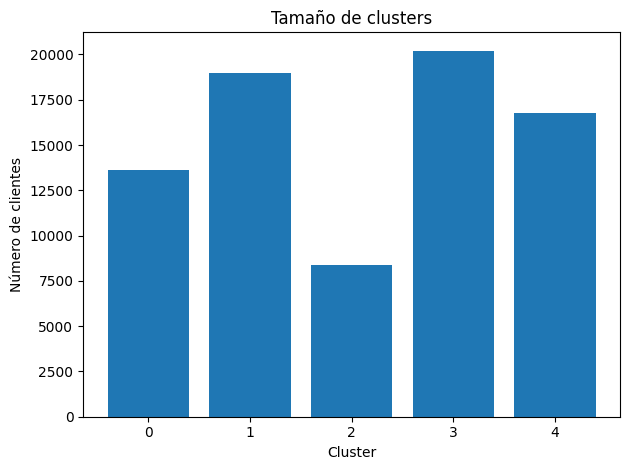

C:\Users\mpsua\AppData\Local\Temp\ipykernel_14268\314509131.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(c) for c in clusters], showfliers=False)


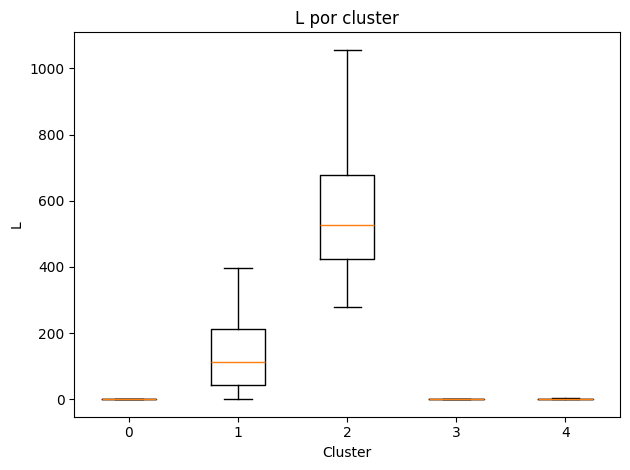

C:\Users\mpsua\AppData\Local\Temp\ipykernel_14268\314509131.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(c) for c in clusters], showfliers=False)


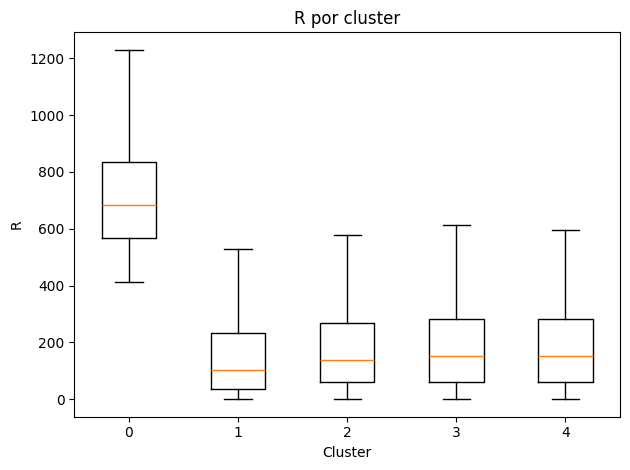

C:\Users\mpsua\AppData\Local\Temp\ipykernel_14268\314509131.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(c) for c in clusters], showfliers=False)


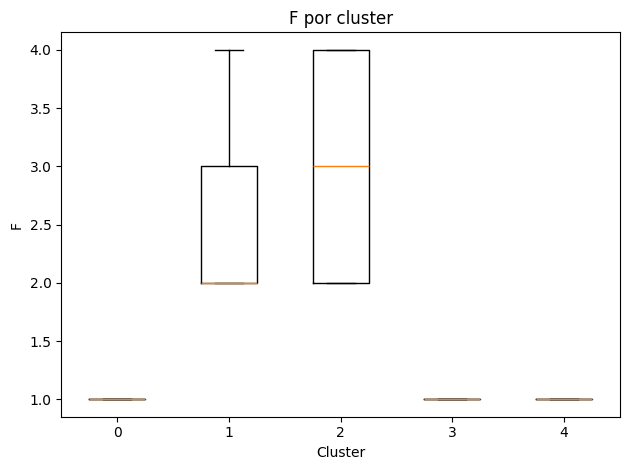

C:\Users\mpsua\AppData\Local\Temp\ipykernel_14268\314509131.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(c) for c in clusters], showfliers=False)


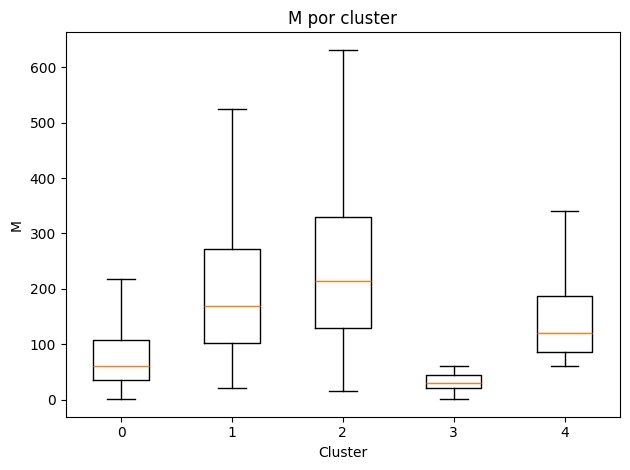

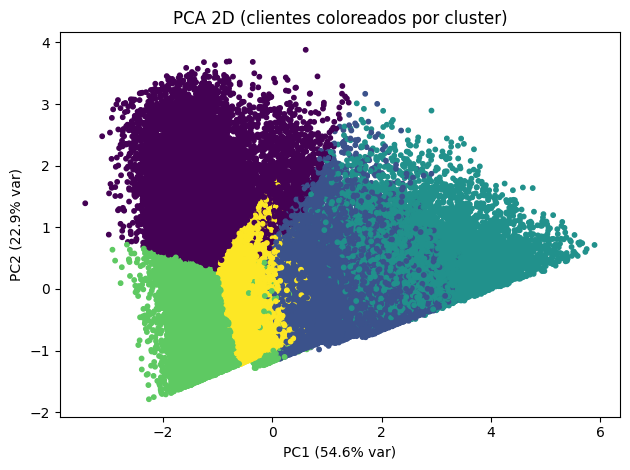

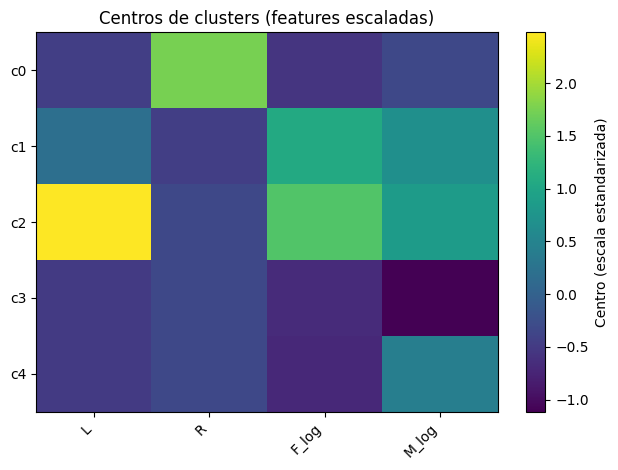

,L,R,F_log,M_log,F_aprox,M_aprox
cluster,,,,,,
0,12.321505,713.475130,0.734671,4.120945,1.084796,60.617472
1,133.540955,154.777620,1.203452,5.129712,2.331598,167.968505
2,565.994626,183.948412,1.328206,5.317251,2.774266,202.822898
3,1.800208,181.402554,0.703140,3.354873,1.020087,27.641960
4,0.892919,180.500686,0.693147,4.884852,1.000000,131.270915


In [59]:
from k_means import KMeansLRFMSegmenter
import importlib
import k_means
importlib.reload(k_means)
from k_means import KMeansLRFMSegmenter


k_final = 5
segmenter = KMeansLRFMSegmenter(n_clusters=k_final)

df_seg = segmenter.fit_predict(df_lrfm)

# 1) tabla resumen
display(resumen_por_cluster(df_seg))

# 2) tamaños
plot_cluster_sizes(df_seg)

# 3) boxplots
for var in ["L", "R", "F", "M"]:
    boxplot_por_cluster(df_seg, var)

# 4) PCA
plot_pca_clusters(segmenter.X_scaled_, df_seg["segmento_id"].values)

# 5) centros
heatmap_centros_escalados(segmenter)

# (opcional) centros en escala original
display(segmenter.get_cluster_centers_original())
